# Athletic Footwear Pricing Analysis
### Competitive Pricing Strategy & Market Segmentation
**Trevor Gergics** | June 2026

---
A data-driven pricing analysis of 1,000+ athletic footwear products across 10 major brands,
identifying competitive positioning strategies, pricing tier structures, and market entry opportunities.

## 1. Data Cleaning & Overview
The dataset contains 1,006 shoe products across 10 brands with attributes including
type, gender, size, color, material, and retail price. Prices were standardized from
string format to float for analysis.

In [ ]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('shoe_prices.csv')

# Check inital file
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

In [ ]:
# Strip the $ and spaces from price, convert to float
df['Price (USD)'] = df['Price (USD)'].str.replace('$', '', regex=False).str.strip()
df['Price (USD)'] = df['Price (USD)'].astype(float)

# Rename the Price column
df = df.rename(columns={'Price (USD)': 'Price'})

# Strip whitespace from all string columns
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Testing if it worked
print(df.dtypes)
print(df['Price'].describe())
print(df.head())

## 2. Brand-Level Pricing Analysis
Examining average retail prices across brands to identify premium vs. value positioning strategies.

             Count  Mean_Price  Median_Price  Min_Price  Max_Price  Std_Dev
Brand                                                                      
Adidas         100      146.55         140.0       25.0      220.0    47.78
Asics          100      130.80         120.0       70.0      180.0    33.96
Nike           118      122.54         120.0       85.0      250.0    34.09
New Balance    100      117.15         110.0       80.0      175.0    30.50
Reebok         100      109.15         120.0       60.0      200.0    30.96
Puma           100      100.90         100.0       65.0      140.0    22.41
Converse       100       77.55          75.0       55.0      120.0    13.92
Skechers        89       71.00          65.0       50.0      125.0    14.67
Fila            99       69.95          70.0       60.0       95.0     6.49
Vans           100       60.00          65.0       50.0       70.0     9.02


/tmp/ipykernel_6028/1389417938.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Brand', y='Price', order=brand_order, palette='Blues_d')


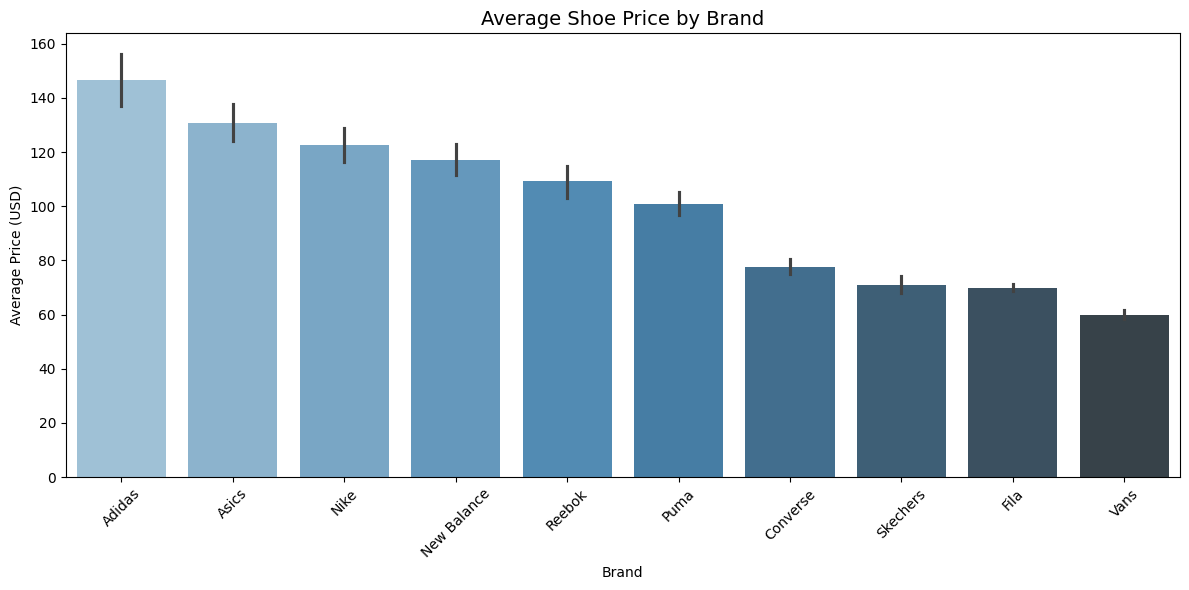

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Brand-level pricing summary
brand_summary = df.groupby('Brand')['Price'].agg(
    Count='count',
    Mean_Price='mean',
    Median_Price='median',
    Min_Price='min',
    Max_Price='max',
    Std_Dev='std'
).round(2).sort_values('Mean_Price', ascending=False)

print(brand_summary)

# Visualize average price by brand
plt.figure(figsize=(12, 6))
brand_order = brand_summary.index.tolist()
sns.barplot(data=df, x='Brand', y='Price', order=brand_order, palette='Blues_d')
plt.title('Average Shoe Price by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight
Adidas and Asics command the highest average retail prices, while Fila and Vans anchor
the value end of the market. This suggests two distinct go-to-market strategies —
premium performance branding vs. accessible lifestyle positioning.

## 3. Pricing by Shoe Category
Analyzing how retail price varies across shoe types to identify which categories
command premium pricing and which are commoditized.

                Count  Mean_Price  Median_Price  Min_Price  Max_Price
Type                                                                 
Weightlifting       4      187.50         200.0     150.00      200.0
Cross-training      1      130.00         130.0     130.00      130.0
Crossfit           11      130.00         130.0     130.00      130.0
CrossFit            3      130.00         130.0     130.00      130.0
Running           332      129.08         120.0      55.00      250.0
Lifestyle          76      122.83         110.0      65.00      220.0
Trail Running       3      113.33         135.0      70.00      135.0
Basketball         52      112.69         120.0      75.00      170.0
Training           34      110.29         130.0      50.00      130.0
Racing              1      110.00         110.0     110.00      110.0
Trail               6       99.17          92.5      70.00      135.0
Retro               3       90.00          90.0      80.00      100.0
Fashion            8

/tmp/ipykernel_6028/389181286.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Price', order=type_order, palette='coolwarm')


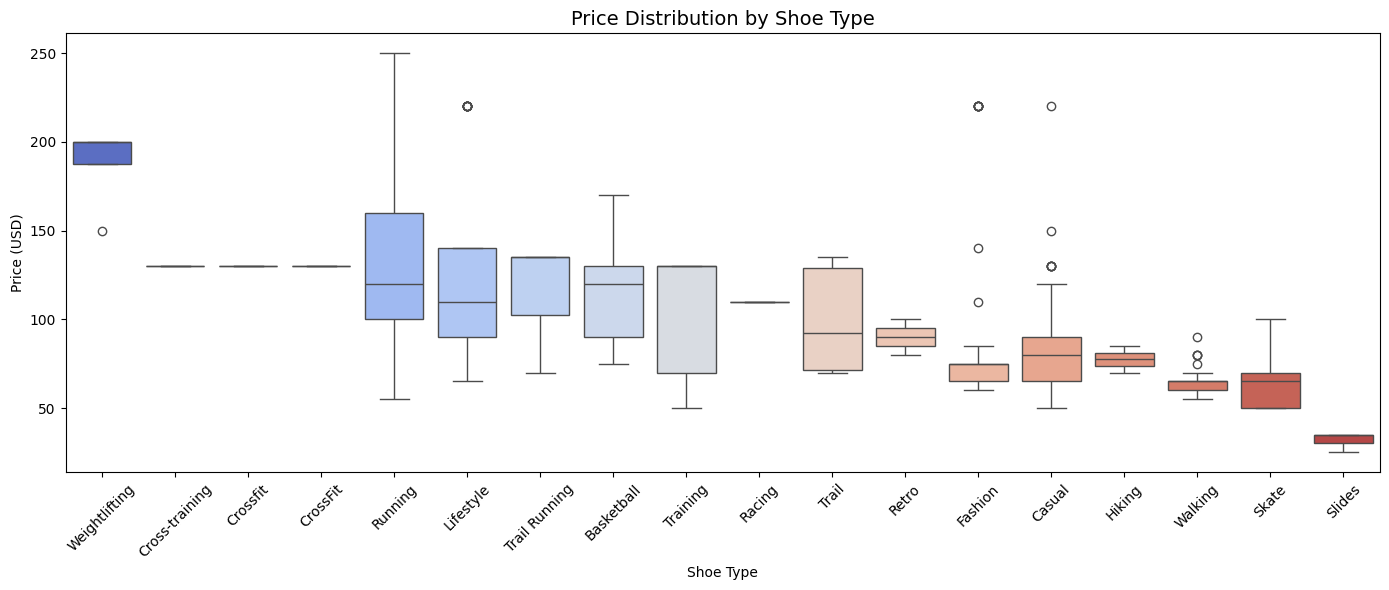

In [ ]:
# Pricing by shoe type/category
type_summary = df.groupby('Type')['Price'].agg(
    Count='count',
    Mean_Price='mean',
    Median_Price='median',
    Min_Price='min',
    Max_Price='max'
).round(2).sort_values('Mean_Price', ascending=False)

print(type_summary)

# Visualize
plt.figure(figsize=(14, 6))
type_order = type_summary.index.tolist()
sns.boxplot(data=df, x='Type', y='Price', order=type_order, palette='coolwarm')
plt.title('Price Distribution by Shoe Type', fontsize=14)
plt.xlabel('Shoe Type')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight
Performance categories (Weightlifting, Running, CrossFit) command a 2–3x price premium
over lifestyle categories (Slides, Skate, Walking). Weightlifting shows near-zero price
variance, indicating a concentrated, consistent pricing market. Running shows the widest
range, reflecting the most competitive and fragmented category.

## 4. Pricing Tier Segmentation
Products are segmented into three tiers based on retail price:

- Budget: 70 USD and under
- Mid-Range: 71 to 120 USD
- Premium: 121 USD and above

Tier
Mid-Range    420
Budget       306
Premium      280
Name: count, dtype: int64

Tier         Budget  Mid-Range  Premium  Total  Premium_%
Brand                                                    
Adidas            3         17       80    100       80.0
Asics             6         47       47    100       47.0
New Balance       0         57       43    100       43.0
Reebok           19         38       43    100       43.0
Nike              0         74       44    118       37.3
Puma             12         66       22    100       22.0
Skechers         64         24        1     89        1.1
Fila             59         40        0     99        0.0
Converse         43         57        0    100        0.0
Vans            100          0        0    100        0.0


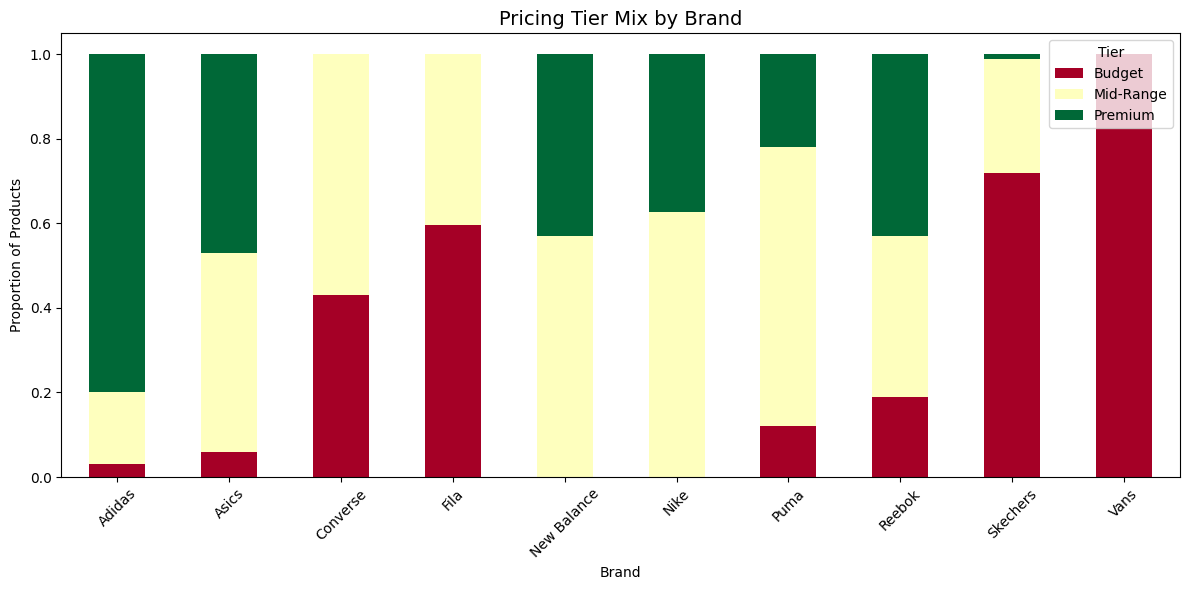

In [ ]:
# Define pricing tiers
def assign_tier(price):
    if price <= 70:
        return 'Budget'
    elif price <= 120:
        return 'Mid-Range'
    else:
        return 'Premium'

df['Tier'] = df['Price'].apply(assign_tier)

# Tier distribution
print(df['Tier'].value_counts())
print()

# Which brands play in which tiers?
brand_tier = pd.crosstab(df['Brand'], df['Tier'])
brand_tier['Total'] = brand_tier.sum(axis=1)
brand_tier['Premium_%'] = (brand_tier['Premium'] / brand_tier['Total'] * 100).round(1)
print(brand_tier.sort_values('Premium_%', ascending=False))

# Visualize tier mix by brand
brand_tier_pct = brand_tier[['Budget', 'Mid-Range', 'Premium']].div(brand_tier['Total'], axis=0)
brand_tier_pct.plot(kind='bar', stacked=True, figsize=(12,6), colormap='RdYlGn')
plt.title('Pricing Tier Mix by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Proportion of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight
Adidas pursues near-exclusive premium positioning (~97% of products above 120 USD),
while Vans and Skechers compete almost entirely on value. Nike spans mid and premium
tiers but leaves the ultra-premium segment (180 USD and above) largely to Adidas,
representing a potential differentiation opportunity.

## 5. Competitive Gap Analysis
Identifying underserved price points in the running shoe segment and overall market
to surface potential market entry or repositioning opportunities.

=== Running Shoes Pricing by Brand ===
             Count  Mean_Price  Min_Price  Max_Price
Brand                                               
Adidas          30      163.67      120.0      180.0
Nike            58      150.52      100.0      250.0
New Balance     57      134.74       80.0      175.0
Asics           94      133.88       70.0      180.0
Reebok          21      113.81       70.0      120.0
Puma            39       99.23       80.0      140.0
Skechers        31       82.42       55.0      125.0
Fila             2       67.50       65.0       70.0


/tmp/ipykernel_6028/2966145365.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=running, x='Brand', y='Price', palette='Blues_d')


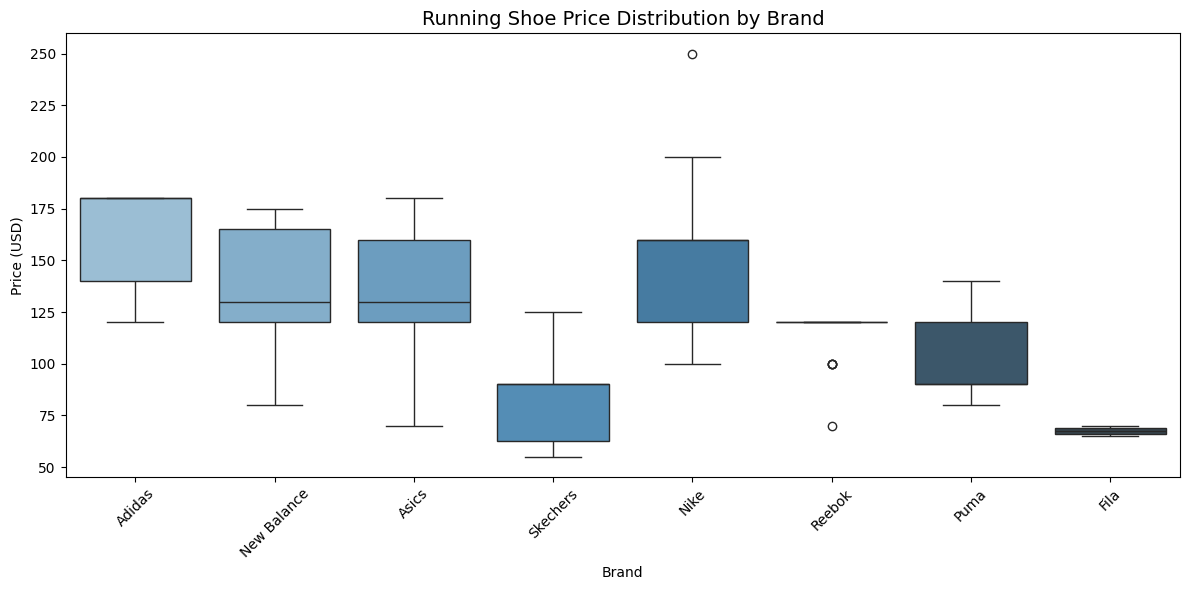

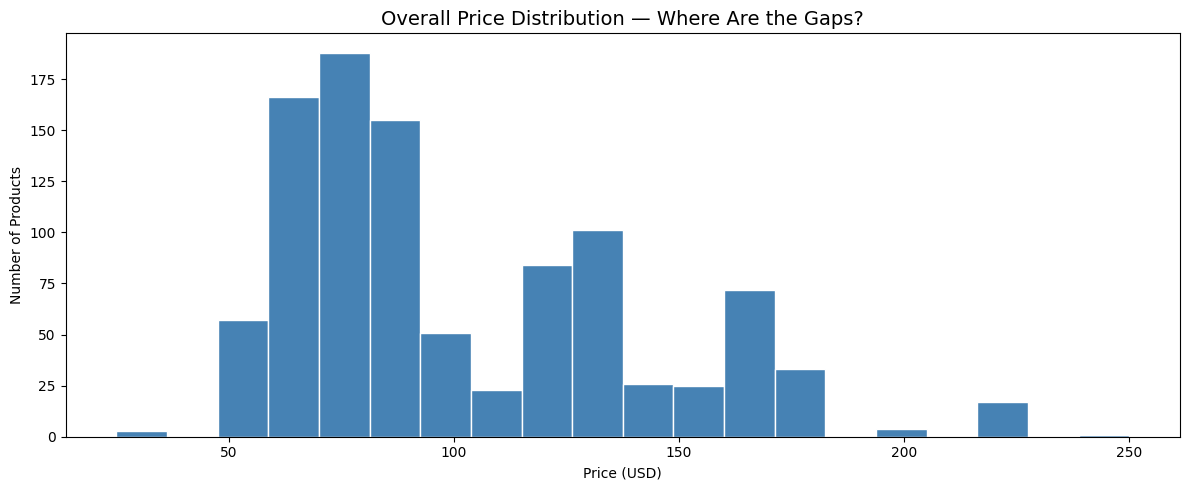

In [ ]:
# Average price by Brand + Type (running shoes specifically)
running = df[df['Type'] == 'Running']

running_brand = running.groupby('Brand')['Price'].agg(
    Count='count',
    Mean_Price='mean',
    Min_Price='min',
    Max_Price='max'
).round(2).sort_values('Mean_Price', ascending=False)

print("=== Running Shoes Pricing by Brand ===")
print(running_brand)

# Visualize running shoes specifically
plt.figure(figsize=(12, 6))
sns.boxplot(data=running, x='Brand', y='Price', palette='Blues_d')
plt.title('Running Shoe Price Distribution by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Find pricing gaps — where is the market underpopulated?
plt.figure(figsize=(12, 5))
plt.hist(df['Price'], bins=20, color='steelblue', edgecolor='white')
plt.title('Overall Price Distribution — Where Are the Gaps?', fontsize=14)
plt.xlabel('Price (USD)')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

## 6. Strategic Recommendations

**Finding 1**: Crowded Value Tier
The 65–90 USD price band contains 40%+ of all products, creating intense commoditization
at the value end. Competing here requires volume scale that most challenger brands cannot achieve.

**Finding 2**: Premium Concentration
Adidas dominates premium pricing with near-exclusive positioning above 140 USD.
Nike's wider price range leaves it less differentiated at the top end.

**Finding 3**: Pricing Gap at 100–110 USD
A significant supply gap exists at the 100–110 USD price point across all categories.
A brand entering this range could capture consumers trading up from budget without
competing directly with established premium players like Adidas or Asics.

**Recommendation**:
For a new market entrant or repositioning brand, target the 95–115 USD range in running shoes,
differentiated by performance materials and positioned as an accessible alternative
to Asics and New Balance — capturing the underserved gap between mass-market and premium.